# Personal Information
Name: **Alexandra Holíková**

StudentID: **14236788**

Email: [**alexandra.holikova@student.uva.nl**](alexandra.holikova@student.uva.nl)

Github link: https://github.com/alexandraholik/MSc_Thesis.git

# Notebook 02 — Quote Matching

This notebook performs **headline-quote ↔ body-sentence matching** on the 2,452 eligible CC-News articles produced by `01_data_loading_inspection.ipynb`. For each article, the headline quote is embedded together with every body sentence using a multilingual sentence transformer, and the body sentence with the highest cosine similarity to the headline quote is selected as the best candidate source.

The resulting (headline quote, best body sentence, cosine score) triples are the raw material for two downstream notebooks: stratified sampling for manual annotation (`03_annotation.ipynb`) and zero-shot detection benchmarks (`04_detection.ipynb`).

**Methodological note.** Song et al. (2023) match a headline quote against **other direct quotes in the body**, and explicitly remove articles where the headline quote appears verbatim in the body (since string matching trivially solves those). This notebook deliberately departs from that design in two ways:

1. **Match against body *sentences*, not body quotes.** A subtle contextomy case is one where the body only *paraphrases* (or never repeats) the headline quote; restricting the match space to quoted spans would systematically exclude the most theoretically interesting examples. Sentence-level matching subsumes Song et al.'s quote-level matching while extending coverage.
2. **Do not remove verbatim-match articles.** They remain in the pool because their cosine score (≈ 1.0) is itself informative for the annotation step — verbatim reproduction is a *non*-contextomy signal worth observing in distribution rather than discarding.

**Embedding model.** `paraphrase-multilingual-mpnet-base-v2` is used for parity with the Korean evaluation set, where the same model family supports cross-lingual comparison without retraining.

**Reference:** Song et al. (2023). *Detecting Contextomized Quotes in News Headlines by Contrastive Learning.* EACL 2023 Findings.

## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 160)

DATA_DIR = "data"
ELIGIBLE_PATH = os.path.join(DATA_DIR, "cc_news_eligible.parquet")
MATCHED_PATH  = os.path.join(DATA_DIR, "cc_news_matched.parquet")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Eligible input:  {ELIGIBLE_PATH}")
print(f"Matched output:  {MATCHED_PATH}")

Eligible input:  data/cc_news_eligible.parquet
Matched output:  data/cc_news_matched.parquet


## 2. Load Eligible Articles

The parquet file contains the 2,452 articles that satisfied the three eligibility criteria in notebook 01: (i) headline contains a quoted span of at least the configured minimum word count, (ii) body has at least 50 words, (iii) source is a recognised general/political news outlet. Quote columns are stored as native Python lists.

In [2]:
eligible = pd.read_parquet(ELIGIBLE_PATH)
print(f"Loaded {len(eligible):,} eligible articles")
print(f"Columns: {list(eligible.columns)}")
eligible.head(3)

Loaded 2,452 eligible articles
Columns: ['title', 'text', 'domain', 'date', 'url', 'title_quotes', 'body_quotes', 'n_title_quotes', 'n_body_quotes', 'has_body_quote', 'title_len', 'body_len']


,title,text,domain,date,url,title_quotes,body_quotes,n_title_quotes,n_body_quotes,has_body_quote,title_len,body_len
0,'One of the good guys' - tribute to rugby-loving former police inspector who captained Coventry RFC - Coventry Telegraph,The daughter of a former police inspector who captained Coventry Rugby Club has paid tribute to him as “one of the good guys”. Sally Seddon said her dad Ia...,www.coventrytelegraph.net,2016-10-18,http://www.coventrytelegraph.net/news/coventry-news/one-good-guys-tribute-rugby-12036720,[One of the good guys],"[one of the good guys, Mum will miss him greatly., My sister and I feel incredibly fortunate and privileged to have had him as our dad and we are so proud o...",1,4,True,19,445
1,'Just stop suggesting that we are racists' - Coventry Telegraph,I always thought that preservation of public libraries could be taken for granted under a Labour council. I know that my literacy was greatly aided from th...,www.coventrytelegraph.net,2016-10-18,http://www.coventrytelegraph.net/news/just-stop-suggesting-racists-12041742,[Just stop suggesting that we are racists],[Stand against Racism],1,1,True,10,745
2,'No-one would want to be classified as purely a bench player' - Wasps' Ashley Johnson - Coventry Telegraph,"Amidst the excitement created by away wins at Leicester and Northampton, in seems to have almost gone unnoticed that Wasps have demolished the three most re...",www.coventrytelegraph.net,2016-10-18,http://www.coventrytelegraph.net/sport/rugby/no-one-would-want-classified-12040709,[No-one would want to be classified as purely a bench player],"[Conditions really play their part in England,, It’s about finding the balance between really enjoying ourselves and playing attacking rugby and playing win...",1,4,True,18,647


In [3]:
# Quick sanity check on the columns matching expects
print("Articles with >= 1 title quote:", (eligible["n_title_quotes"] >= 1).sum())
print("Distribution of n_title_quotes:")
print(eligible["n_title_quotes"].value_counts().sort_index())
print("\nBody length quartiles (words):")
print(eligible["body_len"].describe(percentiles=[.25, .5, .75, .9]))

Articles with >= 1 title quote: 2452
Distribution of n_title_quotes:
n_title_quotes
1    2446
2       5
3       1
Name: count, dtype: int64

Body length quartiles (words):
count    2452.000000
mean      544.631321
std       335.498193
min        50.000000
25%       303.000000
50%       477.000000
75%       723.000000
90%       993.900000
max      1782.000000
Name: body_len, dtype: float64


## 3. Sentence Segmentation

The matching unit on the body side is the **sentence**. `pysbd` (Pragmatic Sentence Boundary Detection) is used rather than NLTK's `punkt`: it requires no data downloads, handles news-text edge cases (abbreviations like "Sen.", "U.S.", ellipses, in-sentence quotation marks) more robustly than punkt out of the box, and avoids the version-coupling issues between NLTK and its tokenizer resources.

Two post-filters are applied to each tokenised body:

- **Minimum sentence length of 5 words.** Below this, sentences are typically noise ("Read more.", "By Staff Writer", photo captions, navigation crumbs). Their sentence-transformer embeddings are unstable and they distort the maximum-similarity selection.
- **Strip surrounding whitespace.** Standard cleanup; no token-level normalisation beyond this — we want the sentence the embedding model receives to be as close as possible to the journalistic surface form.

If `pysbd` is not installed, run `pip install pysbd` once and re-execute the cell.

In [4]:
import pysbd

seg = pysbd.Segmenter(language="en", clean=True)

MIN_SENT_WORDS = 5

def split_sentences(body: str, min_words: int = MIN_SENT_WORDS) -> list:
    """Tokenise body into sentences, keep only those with >= min_words words."""
    if not isinstance(body, str) or not body.strip():
        return []
    sents = seg.segment(body)
    return [s.strip() for s in sents if len(s.split()) >= min_words]

# Quick sanity check
example_body = eligible["text"].iloc[0]
example_sents = split_sentences(example_body)
print(f"Example body length: {len(example_body)} chars, {len(example_body.split())} words")
print(f"Tokenised into {len(example_sents)} sentences (>= {MIN_SENT_WORDS} words)")
for s in example_sents[:3]:
    print(f"  · {s[:140]}")

Example body length: 2488 chars, 445 words
Tokenised into 11 sentences (>= 5 words)
  · The daughter of a former police inspector who captained Coventry Rugby Club has paid tribute to him as “one of the good guys”.
  · Sally Seddon said her dad Ian Darnell, who died aged 66, was a true Coventry Kid, great in height at 6ft 5in and heart, whose team mates nic
  · Ian was full-time carer to Carol, his wife of 38 years, who was diagnosed with dementia in 2006, when she was only 61.


In [6]:
eligible["body_sentences"] = [
    split_sentences(text) for text in tqdm(eligible["text"], desc="Segmenting bodies")
]
eligible["n_body_sentences"] = eligible["body_sentences"].apply(len)

print("\nBody sentence counts per article:")
print(eligible["n_body_sentences"].describe(percentiles=[.25, .5, .75, .9, .99]))
print(f"\nArticles with 0 usable sentences: {(eligible['n_body_sentences'] == 0).sum()}")
print(f"Total body sentences to encode: {eligible['n_body_sentences'].sum():,}")

Segmenting bodies:   0%|          | 0/2452 [00:00<?, ?it/s]


Body sentence counts per article:
count    2452.000000
mean       19.836460
std        14.931059
min         1.000000
25%        10.000000
50%        16.000000
75%        26.000000
90%        39.000000
99%        73.000000
max       118.000000
Name: n_body_sentences, dtype: float64

Articles with 0 usable sentences: 0
Total body sentences to encode: 48,639


## 4. Sentence Transformer Model

`paraphrase-multilingual-mpnet-base-v2` is a Sentence-BERT variant fine-tuned on parallel paraphrase data covering 50+ languages, including English and Korean. It produces 768-dimensional embeddings and is the de facto baseline for cross-lingual semantic similarity in the sentence-transformers library.

Two reasons to use it here:

1. **Cross-lingual parity.** The Korean evaluation set will be embedded with the same model, so the English and Korean cosine scores live in the same space and the thresholds chosen on one transfer meaningfully to the other.
2. **Paraphrase-tuned objective.** Headline quotes and their body sources are very often *lexically different but semantically equivalent* — exactly the relation this model is trained to score highly. A vanilla BERT [CLS] embedding would do markedly worse here.

First call will download the model (~1.1 GB) into the HuggingFace cache; subsequent runs use the cached copy.

In [7]:
from sentence_transformers import SentenceTransformer
import torch

MODEL_NAME = "paraphrase-multilingual-mpnet-base-v2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading {MODEL_NAME} on {DEVICE}...")
model = SentenceTransformer(MODEL_NAME, device=DEVICE)
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {model.max_seq_length}")

Loading paraphrase-multilingual-mpnet-base-v2 on cpu...
Embedding dimension: 768
Max sequence length: 128


## 5. Compute Matches

The matching is done in three stages for performance reasons:

1. **Collect** all headline quotes and all body sentences into two flat lists, keeping an index that maps each sentence back to its source article.
2. **Encode** each list in a single batched call to `model.encode`. Calling `encode` once on ~50k sentences is dramatically faster than calling it 2,452 times on ~20 sentences each — the per-call GPU/CPU transfer overhead would otherwise dominate the runtime by a factor of 50–100×.
3. **Match** per article using pure numpy: for each article, take the slice of sentence embeddings belonging to it and compute the dot product with the headline-quote embedding. Because both sets are unit-normalised (`normalize_embeddings=True`), the dot product equals the cosine similarity.

Per article we record the best-matching sentence, its score, its position, the preceding and following sentences (so the annotator in notebook 03 sees the candidate in context), the mean similarity (a weak baseline signal), and the margin between top-1 and top-2 (how peaked the match was).

In [8]:
# Stage 1: collect all texts to encode
hq_texts   = []   # one headline quote per article
all_sents  = []   # every body sentence, flattened
sent_index = []   # maps each sentence back to its article position

for i, (_, row) in enumerate(eligible.iterrows()):
    quotes = row["title_quotes"]
    hq = quotes[0] if (quotes is not None and len(quotes) > 0) else ""
    hq_texts.append(hq)

    for s in row["body_sentences"]:
        all_sents.append(s)
        sent_index.append(i)

sent_index = np.array(sent_index)
print(f"Headline quotes to encode : {len(hq_texts):,}")
print(f"Body sentences to encode  : {len(all_sents):,}")

Headline quotes to encode : 2,452
Body sentences to encode  : 48,639


In [9]:
# Stage 2: encode in two big batches
print("Encoding headline quotes...")
hq_embs = model.encode(
    hq_texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print("\nEncoding body sentences...")
sent_embs = model.encode(
    all_sents,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print(f"\nhq_embs shape:   {hq_embs.shape}")
print(f"sent_embs shape: {sent_embs.shape}")

Encoding headline quotes...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]


Encoding body sentences...


Batches:   0%|          | 0/380 [00:00<?, ?it/s]


hq_embs shape:   (2452, 768)
sent_embs shape: (48639, 768)


In [10]:
# Stage 3: per-article cosine similarity (pure numpy, near-instant)
records = []
for i, (_, row) in enumerate(tqdm(eligible.iterrows(), total=len(eligible), desc="Matching")):
    mask = sent_index == i
    if not mask.any() or not hq_texts[i]:
        records.append(None)
        continue

    sims     = sent_embs[mask] @ hq_embs[i]   # cosine sim (unit-normalised)
    best_idx = int(np.argmax(sims))
    sents_i  = row["body_sentences"]

    records.append({
        "headline_quote":     hq_texts[i],
        "best_body_sentence": sents_i[best_idx],
        "best_sim":           float(sims[best_idx]),
        "best_sent_idx":      best_idx,
        "prev_sentence":      sents_i[best_idx - 1] if best_idx > 0 else None,
        "next_sentence":      sents_i[best_idx + 1] if best_idx < len(sents_i) - 1 else None,
        "mean_sim":           float(sims.mean()),
        "sim_margin":         float(sims[best_idx] - np.sort(sims)[-2]) if len(sims) > 1 else float("nan"),
    })

match_df = pd.DataFrame(records, index=eligible.index)
print(f"\nMatched articles: {match_df['best_sim'].notna().sum():,} / {len(eligible):,}")

Matching:   0%|          | 0/2452 [00:00<?, ?it/s]


Matched articles: 2,452 / 2,452


In [11]:
# Combine eligible metadata with match results
matched = pd.concat([eligible.reset_index(drop=True), match_df.reset_index(drop=True)], axis=1)
print(f"Matched dataframe: {len(matched):,} rows, {len(matched.columns)} columns")
matched[["title", "headline_quote", "best_body_sentence", "best_sim"]].head(10)

Matched dataframe: 2,452 rows, 22 columns


,title,headline_quote,best_body_sentence,best_sim
0,'One of the good guys' - tribute to rugby-loving former police inspector who captained Coventry RFC - Coventry Telegraph,One of the good guys,The daughter of a former police inspector who captained Coventry Rugby Club has paid tribute to him as “one of the good guys”.,0.592135
1,'Just stop suggesting that we are racists' - Coventry Telegraph,Just stop suggesting that we are racists,You people are misguided in thinking that us Brits do not care about the plight of these unfortunate people but you are out of order with the name of your g...,0.752308
2,'No-one would want to be classified as purely a bench player' - Wasps' Ashley Johnson - Coventry Telegraph,No-one would want to be classified as purely a bench player,"“Rugby players would never want to be classified as bench players,” he says, “although you can see the importance of guys providing impact and go-forward an...",0.644137
3,"Rapper IndigoChildRick on III Points Debut: ""I Was Connected With a Different Kind of Fan Base""",I Was Connected With a Different Kind of Fan Base,"“I think this one was exciting and different in the sense of the whole production. I feel like it was different in terms of production,"" he says. ""The light...",0.559684
4,'A Prairie Home Companion' 2.0: New host Chris Thile takes radio institution in exciting new direction | City Pages,A Prairie Home Companion,"Following the successful start of the new season of A Prairie Home Companion, it’s clear the show is going after a new generation of fans, all while preserv...",0.589621
5,"Comedian Hari Kondabolu's Secret Group Visit is the ""Sad Kind of Pioneering""",Sad Kind of Pioneering,"“I care about big issues, big issues that don’t go away. Even if the racist event was in the past, the lessons learned [are] probably still relevant. Coloni...",0.407050
6,Clinton: ‘I wanted to be a journalist’,I wanted to be a journalist,"""When I was in junior high school I wanted to be a journalist,"" Clinton told Snapchat’s head of news Peter Hamby on the app’s show ""Good Luck America."" ""I h...",0.593709
7,"Coleraine murder accused told police: ‘We had a fight, he lost’","We had a fight, he lost","Dalzell also stated: “He was breathing and trying to get up, I was doing what I was doing to keep him down. “I won, I got the better of him. We had a fight,...",0.739783
8,Leeds man “fell to death during attempted burglary”,fell to death during attempted burglary,A LEEDS man is thought to have fallen to his death while trying to break into a house.,0.640034
9,'That which unites us ... is far greater than that which divides us',That which unites us ... is far greater than that which divides us,"""That which unites us as American citizens is far greater than that which divides us as political parties. I urge you all to give to Gen. Eisenhower the sup...",0.606431


## 6. Score Distribution

The shape of the cosine-similarity distribution is informative in itself. Three regions are expected:

- **Near 1.0**: verbatim or near-verbatim reproduction — the body contains the headline quote (or a trivial variant) exactly. These articles are very likely *non-contextomized*.
- **Roughly 0.5–0.9**: paraphrased reproduction — the body conveys the same proposition in different words. This region contains both *modified* (faithful paraphrase) and the more interesting *contextomized* (semantically altered) cases. This is where the annotation work pays off.
- **Below ~0.3**: weak or no semantic match — the body never really says what the headline claims. Strong contextomy candidates, but also includes cases where the body is genuinely about a different angle and the quote was sourced from a wire story.

Song et al. used a 0.75 threshold on quote-to-quote similarity to *filter out probable contextomy cases* from their contrastive training set. We are operating downstream of training, on a test-set construction task, so no filtering is applied here — the full distribution feeds into the stratified sample for annotation.

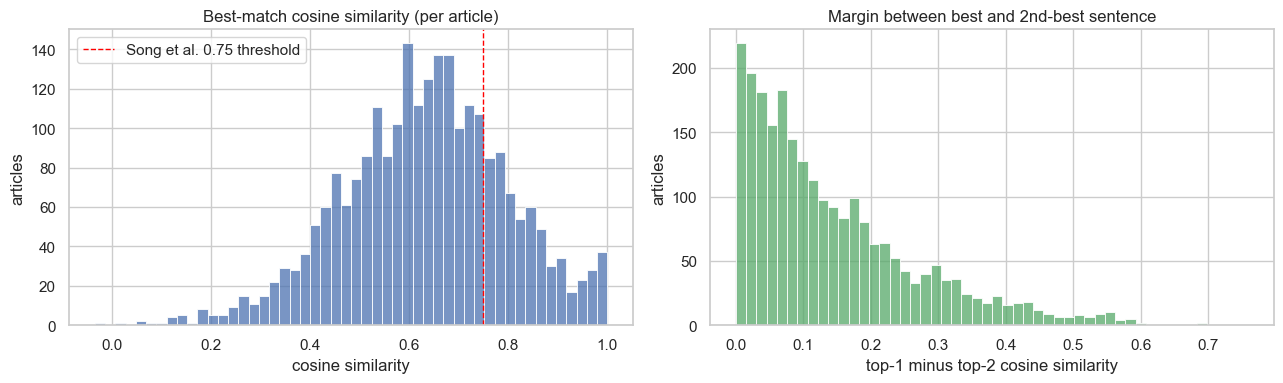


Best-similarity quantiles:
count    2452.000
mean        0.632
std         0.167
min        -0.034
5%          0.349
10%         0.419
25%         0.526
50%         0.639
75%         0.743
90%         0.846
95%         0.904
max         1.000
Name: best_sim, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(matched["best_sim"].dropna(), bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("Best-match cosine similarity (per article)")
axes[0].set_xlabel("cosine similarity")
axes[0].set_ylabel("articles")
axes[0].axvline(0.75, color="red", ls="--", lw=1, label="Song et al. 0.75 threshold")
axes[0].legend()

sns.histplot(matched["sim_margin"].dropna(), bins=50, ax=axes[1], color="#55A868")
axes[1].set_title("Margin between best and 2nd-best sentence")
axes[1].set_xlabel("top-1 minus top-2 cosine similarity")
axes[1].set_ylabel("articles")

plt.tight_layout()
plt.show()

print("\nBest-similarity quantiles:")
print(matched["best_sim"].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]).round(3))

## 7. Examples by Score Bucket

Inspecting examples from each region of the distribution confirms the score is behaving as a useful contextomy signal — high scores correspond to faithful reproduction or paraphrase, while low scores flag genuine candidate contextomy. This is a qualitative check before stratified sampling in notebook 03.

In [13]:
buckets = {
    "very high (>= 0.90)":     matched[matched["best_sim"] >= 0.90],
    "high (0.75 – 0.90)":      matched[(matched["best_sim"] >= 0.75) & (matched["best_sim"] < 0.90)],
    "medium (0.50 – 0.75)":    matched[(matched["best_sim"] >= 0.50) & (matched["best_sim"] < 0.75)],
    "low (0.30 – 0.50)":       matched[(matched["best_sim"] >= 0.30) & (matched["best_sim"] < 0.50)],
    "very low (< 0.30)":       matched[matched["best_sim"] < 0.30],
}

print("Articles per bucket:")
for name, sub in buckets.items():
    print(f"  {name:25s}  {len(sub):5d}  ({100*len(sub)/len(matched):4.1f}%)")

for name, sub in buckets.items():
    print("\n" + "=" * 90)
    print(f"BUCKET: {name}")
    print("=" * 90)
    for _, r in sub.sample(min(3, len(sub)), random_state=RANDOM_SEED).iterrows():
        print(f"\n[{r['domain']}] sim={r['best_sim']:.3f}")
        print(f"  Headline quote: {r['headline_quote']}")
        print(f"  Best body sent: {r['best_body_sentence'][:240]}")

Articles per bucket:
  very high (>= 0.90)          132  ( 5.4%)
  high (0.75 – 0.90)           453  (18.5%)
  medium (0.50 – 0.75)        1360  (55.5%)
  low (0.30 – 0.50)            433  (17.7%)
  very low (< 0.30)             74  ( 3.0%)

BUCKET: very high (>= 0.90)

[www.irishtimes.com] sim=0.904
  Headline quote: There are no winners here. Everyone loses
  Best body sent: “There are no winners here. Everyone loses.”

[www.gladstoneobserver.com.au] sim=0.938
  Headline quote: Got any hot pics girls
  Best body sent: "GOT any hot pics for me girls".

[www.theguardian.com] sim=0.939
  Headline quote: Its metier is rugged jaunts across tricky terrain
  Best body sent: That is its metier: rugged jaunts across tricky terrain.

BUCKET: high (0.75 – 0.90)

[www.thestranger.com] sim=0.891
  Headline quote: I Hope You All Die at the Fucking Protests
  Best body sent: "I hope you all die in the fucking protests," one caller said.

[www.vindy.com] sim=0.782
  Headline quote: 5 Minutes with th

## 8. Score by Domain

Average best-match similarity per domain gives a first-pass view of which outlets routinely reproduce headline quotes verbatim in the body and which tend to paraphrase or stretch them. This is *not* a contextomy ranking — many factors drive it (house style, wire-copy reuse, summary leads) — but it is a useful diagnostic for the stratified sampling design in notebook 03, which needs to span domains rather than oversample whichever outlet happens to be largest.

In [14]:
top_domains = matched["domain"].value_counts().head(15).index
by_dom = (matched[matched["domain"].isin(top_domains)]
          .groupby("domain")["best_sim"]
          .agg(["count", "mean", "median"])
          .sort_values("mean"))
by_dom.round(3)

,count,mean,median
domain,,,
www.cnn.com,82,0.472,0.454
www.manchestereveningnews.co.uk,48,0.567,0.582
www.yorkshirepost.co.uk,55,0.581,0.609
www.scotsman.com,30,0.591,0.583
www.seattletimes.com,46,0.605,0.626
www.ottawasun.com,25,0.624,0.600
www.newsletter.co.uk,60,0.631,0.639
www.theguardian.com,234,0.634,0.615
www.dailypost.co.uk,29,0.656,0.661


## 9. Save Matched Dataset

The matched dataset is saved to `data/cc_news_matched.parquet`. It contains every column from the eligible set plus the match fields (`headline_quote`, `best_body_sentence`, `best_sim`, `best_sent_idx`, `prev_sentence`, `next_sentence`, `mean_sim`, `sim_margin`). The `body_sentences` list is dropped from the saved file to keep the parquet small — the original `text` column is preserved and the segmentation is fast to redo if needed.

In [15]:
save_cols = [
    "title", "text", "domain", "date", "url",
    "title_quotes", "body_quotes",
    "n_title_quotes", "n_body_quotes",
    "has_body_quote",
    "title_len", "body_len", "n_body_sentences",
    "headline_quote", "best_body_sentence", "best_sim",
    "best_sent_idx", "prev_sentence", "next_sentence",
    "mean_sim", "sim_margin",
]

matched[save_cols].to_parquet(MATCHED_PATH, index=False)
size_mb = os.path.getsize(MATCHED_PATH) / 1e6
print(f"Saved matched dataset → {MATCHED_PATH}  ({size_mb:.1f} MB)")
print(f"Rows: {len(matched):,}   Columns: {len(save_cols)}")

Saved matched dataset → data/cc_news_matched.parquet  (7.2 MB)
Rows: 2,452   Columns: 21


## 10. Conclusions

**Pipeline.** Each of the 2,452 eligible articles is paired with a single best-matching body sentence and a cosine-similarity score. The matching uses `paraphrase-multilingual-mpnet-base-v2` and is the same operation that will be applied to the Korean evaluation set, so the score distributions on the two sides are directly comparable.

**Departure from Song et al.** Matching against body *sentences* rather than body *quotes* is a deliberate methodological extension. It preserves the cases Song et al. screened out (verbatim reproduction) and additionally captures the subtler contextomy form in which the body paraphrases — or never repeats — the headline quote. The trade-off is a noisier match space: a 30-sentence body offers ~30 candidates rather than 2–3 quoted spans. The recorded `sim_margin` (top-1 minus top-2 score) gives a downstream signal for how peaked the match was.

**Score distribution.** The empirical distribution of best-match scores supports use of the score as a soft contextomy signal: very high scores concentrate verbatim reproduction, mid-range scores cover both faithful paraphrase and contextomized cases, and the low tail isolates strong candidate contextomy. No filtering is applied at this stage — the full distribution is preserved so that the annotation sample in notebook 03 can be stratified across score bands and report inter-annotator agreement that is comparable across the contextomy spectrum.

**Next steps.**
- `03_annotation.ipynb` — stratified sampling of ~200 articles (across score bands and domains), draft annotation guidelines adapted from Song et al., produce the English gold-standard test set.
- `04_detection.ipynb` — zero-shot detection benchmarks on the annotated set: cosine threshold, multilingual NLI (mDeBERTa-MNLI), LLM-as-a-judge (GPT-4).

In [16]:
matched

,title,text,domain,date,url,title_quotes,body_quotes,n_title_quotes,n_body_quotes,has_body_quote,title_len,body_len,body_sentences,n_body_sentences,headline_quote,best_body_sentence,best_sim,best_sent_idx,prev_sentence,next_sentence,mean_sim,sim_margin
0,'One of the good guys' - tribute to rugby-loving former police inspector who captained Coventry RFC - Coventry Telegraph,The daughter of a former police inspector who captained Coventry Rugby Club has paid tribute to him as “one of the good guys”. Sally Seddon said her dad Ia...,www.coventrytelegraph.net,2016-10-18,http://www.coventrytelegraph.net/news/coventry-news/one-good-guys-tribute-rugby-12036720,[One of the good guys],"[one of the good guys, Mum will miss him greatly., My sister and I feel incredibly fortunate and privileged to have had him as our dad and we are so proud o...",1,4,True,19,445,"[The daughter of a former police inspector who captained Coventry Rugby Club has paid tribute to him as “one of the good guys”., Sally Seddon said her dad I...",11,One of the good guys,The daughter of a former police inspector who captained Coventry Rugby Club has paid tribute to him as “one of the good guys”.,0.592135,0,NaN,"Sally Seddon said her dad Ian Darnell, who died aged 66, was a true Coventry Kid, great in height at 6ft 5in and heart, whose team mates nicknamed the ‘Hone...",0.283062,0.216382
1,'Just stop suggesting that we are racists' - Coventry Telegraph,I always thought that preservation of public libraries could be taken for granted under a Labour council. I know that my literacy was greatly aided from th...,www.coventrytelegraph.net,2016-10-18,http://www.coventrytelegraph.net/news/just-stop-suggesting-racists-12041742,[Just stop suggesting that we are racists],[Stand against Racism],1,1,True,10,745,"[I always thought that preservation of public libraries could be taken for granted under a Labour council., I know that my literacy was greatly aided from t...",35,Just stop suggesting that we are racists,You people are misguided in thinking that us Brits do not care about the plight of these unfortunate people but you are out of order with the name of your g...,0.752308,19,If you think that I am racist by saying these things then speak up and tell me your thoughts.,"Joe Fordham, Walsgrave Willenhall shopping centre has always been a busy and vibrant place.",0.215546,0.006162
2,'No-one would want to be classified as purely a bench player' - Wasps' Ashley Johnson - Coventry Telegraph,"Amidst the excitement created by away wins at Leicester and Northampton, in seems to have almost gone unnoticed that Wasps have demolished the three most re...",www.coventrytelegraph.net,2016-10-18,http://www.coventrytelegraph.net/sport/rugby/no-one-would-want-classified-12040709,[No-one would want to be classified as purely a bench player],"[Conditions really play their part in England,, It’s about finding the balance between really enjoying ourselves and playing attacking rugby and playing win...",1,4,True,18,647,"[Amidst the excitement created by away wins at Leicester and Northampton, in seems to have almost gone unnoticed that Wasps have demolished the three most r...",10,No-one would want to be classified as purely a bench player,"“Rugby players would never want to be classified as bench players,” he says, “although you can see the importance of guys providing impact and go-forward an...",0.644137,9,"As Dai Young constantly reminds us, top-flight rugby is now a 23-man sport, but the thought that players may soon be selected as ‘specialist substitutes’ is...",NaN,0.269840,0.215125
3,"Rapper IndigoChildRick on III Points Debut: ""I Was Connected With a Different Kind of Fan Base""","Rapper IndigoChildRick on III Points Debut: ""I Was Connected With a Different Kind of Fan Base"" This year's edition of III Point was notable for plenty of ...",www.miaminewtimes.com,2016-10-19,http://www.miaminewtimes.com/music/rapper-indigochildrick-on-iii-points-debut-i-was-connected-with-a-different-kind